In [24]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

In [5]:
ii, jj = 178, 288
dd = 5

In [2]:
bathy = xr.open_dataset('/home/sallen/MEOPAR/grid/bathymetry_202108.nc')

In [47]:
bdepth = bathy.Bathymetry[ii, jj].values
bdepth

array(135.)

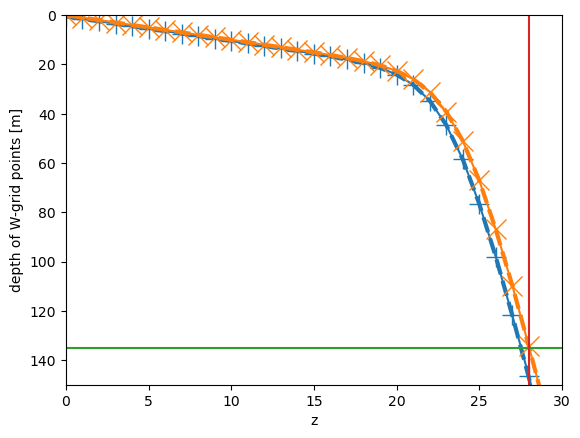

In [100]:
fig, ax = plt.subplots(1, 1)
mesh.gdept_1d[0].plot(ax=ax, yincrease=False, linestyle='--', linewidth=3, c='tab:blue')
mesh.gdept_0[0, :, ii, jj].plot(ax=ax, marker='+', yincrease=False, markersize=15)
mesh.gdepw_1d[0].plot(ax=ax, yincrease=False, linestyle='--', linewidth=3, c='tab:orange')
mesh.gdepw_0[0, :, ii, jj].plot(ax=ax, marker='x', yincrease=False, markersize=15)
ax.plot(range(0, 40), 135*np.ones((40)))
ax.plot(np.ones(2)*mb, [0, 150])
ax.set_ylim(150, 0)
ax.set_xlim(0, 30);

In [8]:
mesh = xr.open_dataset('/home/sallen/MEOPAR/grid/mesh_mask202108.nc')

In [31]:
mb = mesh.mbathy[0, ii, jj].values
mb

array(28, dtype=int16)

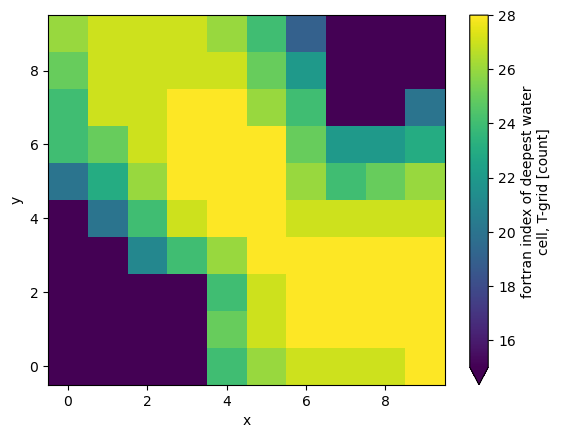

In [14]:
mesh.mbathy[0, ii-dd:ii+dd, jj-dd:jj+dd].plot(vmin=15);

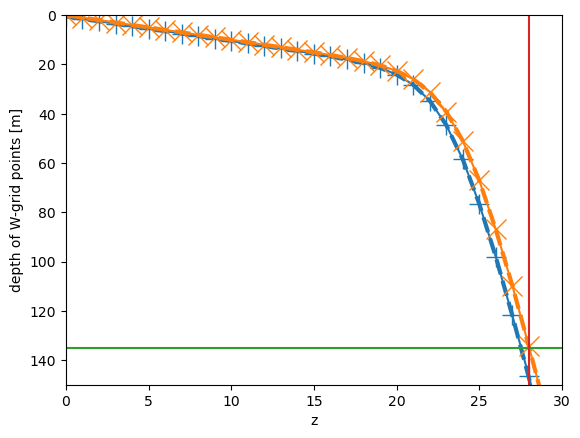

In [39]:
fig, ax = plt.subplots(1, 1)
mesh.gdept_1d[0].plot(ax=ax, yincrease=False, linestyle='--', linewidth=3, c='tab:blue')
mesh.gdept_0[0, :, ii, jj].plot(ax=ax, marker='+', yincrease=False, markersize=15)
mesh.gdepw_1d[0].plot(ax=ax, yincrease=False, linestyle='--', linewidth=3, c='tab:orange')
mesh.gdepw_0[0, :, ii, jj].plot(ax=ax, marker='x', yincrease=False, markersize=15)
ax.plot(range(0, 40), 135*np.ones((40)))
ax.plot(np.ones(2)*mb, [0, 150])
ax.set_ylim(150, 0)
ax.set_xlim(0, 30);

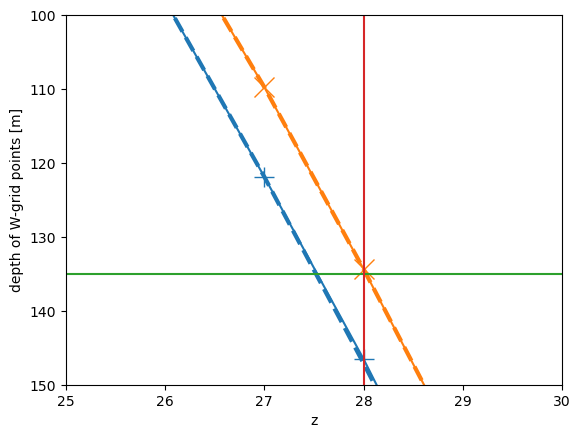

In [41]:
fig, ax = plt.subplots(1, 1)
mesh.gdept_1d[0].plot(ax=ax, yincrease=False, linestyle='--', linewidth=3, c='tab:blue')
mesh.gdept_0[0, :, ii, jj].plot(ax=ax, marker='+', yincrease=False, markersize=15)
mesh.gdepw_1d[0].plot(ax=ax, yincrease=False, linestyle='--', linewidth=3, c='tab:orange')
mesh.gdepw_0[0, :, ii, jj].plot(ax=ax, marker='x', yincrease=False, markersize=15)
ax.plot(range(0, 40), 135*np.ones((40)))
ax.plot(np.ones(2)*mb, [0, 150])
ax.set_ylim(150, 100)
ax.set_xlim(25, 30);

if mbathy = 28, gdept[mbathy-1] is last water cell (-1 because of the move from fortran to python), but the bottom of the grid cell is gdepw[mbathy] 

In [46]:
print (mesh.gdepw_0[0, mb, ii, jj].values)

134.34593


In [87]:
print (mesh.gdepw_1d[0, 20:30].values)

[ 22.61306387  25.93741305  31.10103509  39.1188566   50.96323669
  67.05207424  86.96747037 109.73706598 134.34593444 160.02956159]


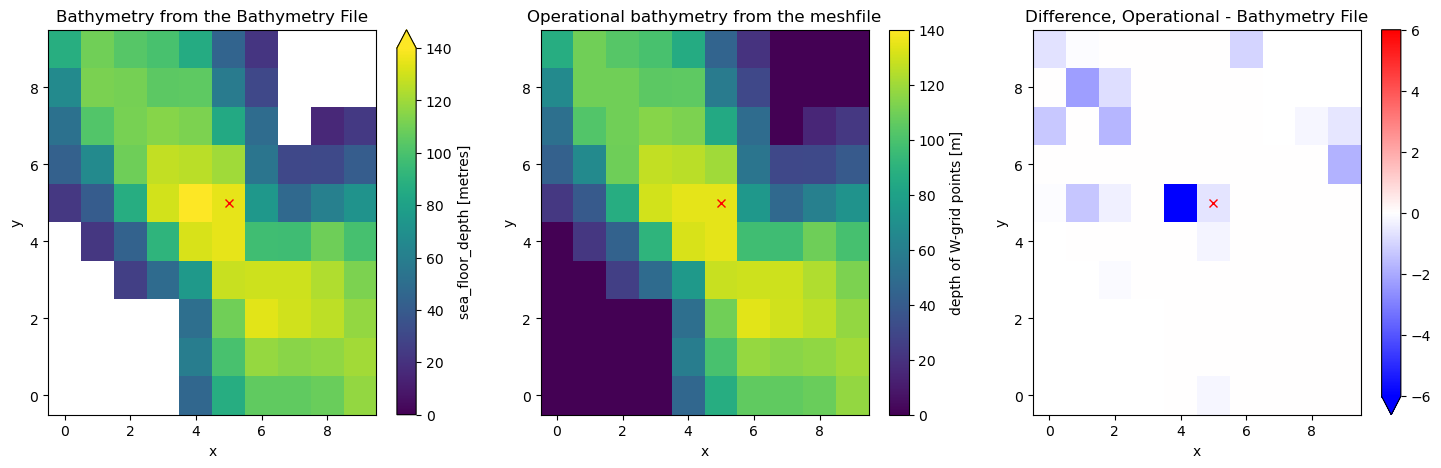

In [95]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
bathy.Bathymetry[ii-dd:ii+dd, jj-dd:jj+dd].plot(ax=axs[0], vmax=140, vmin=0)
mesh.gdepw_0[0, mesh.mbathy[0, ii-dd:ii+dd, jj-dd:jj+dd], ii-dd:ii+dd, jj-dd:jj+dd].plot(ax=axs[1], vmax=140, vmin=0)
(mesh.gdepw_0[0, mesh.mbathy[0, ii-dd:ii+dd, jj-dd:jj+dd], ii-dd:ii+dd, jj-dd:jj+dd] -
    bathy.Bathymetry[ii-dd:ii+dd, jj-dd:jj+dd]).plot(ax=axs[2], cmap='bwr', vmax=6, vmin=-6);
for ax in axs:
    ax.plot(5, 5, 'rx')
axs[0].set_title("Bathymetry from the Bathymetry File")
axs[1].set_title("Operational bathymetry from the meshfile")
axs[2].set_title("Difference, Operational - Bathymetry File");

Mostly the bathymetry values are maintained in the operational grid. All changes are negative. There are a few values that have larger changes. The change at our central point is smallish but not zero.  Lets plot x-sections. 

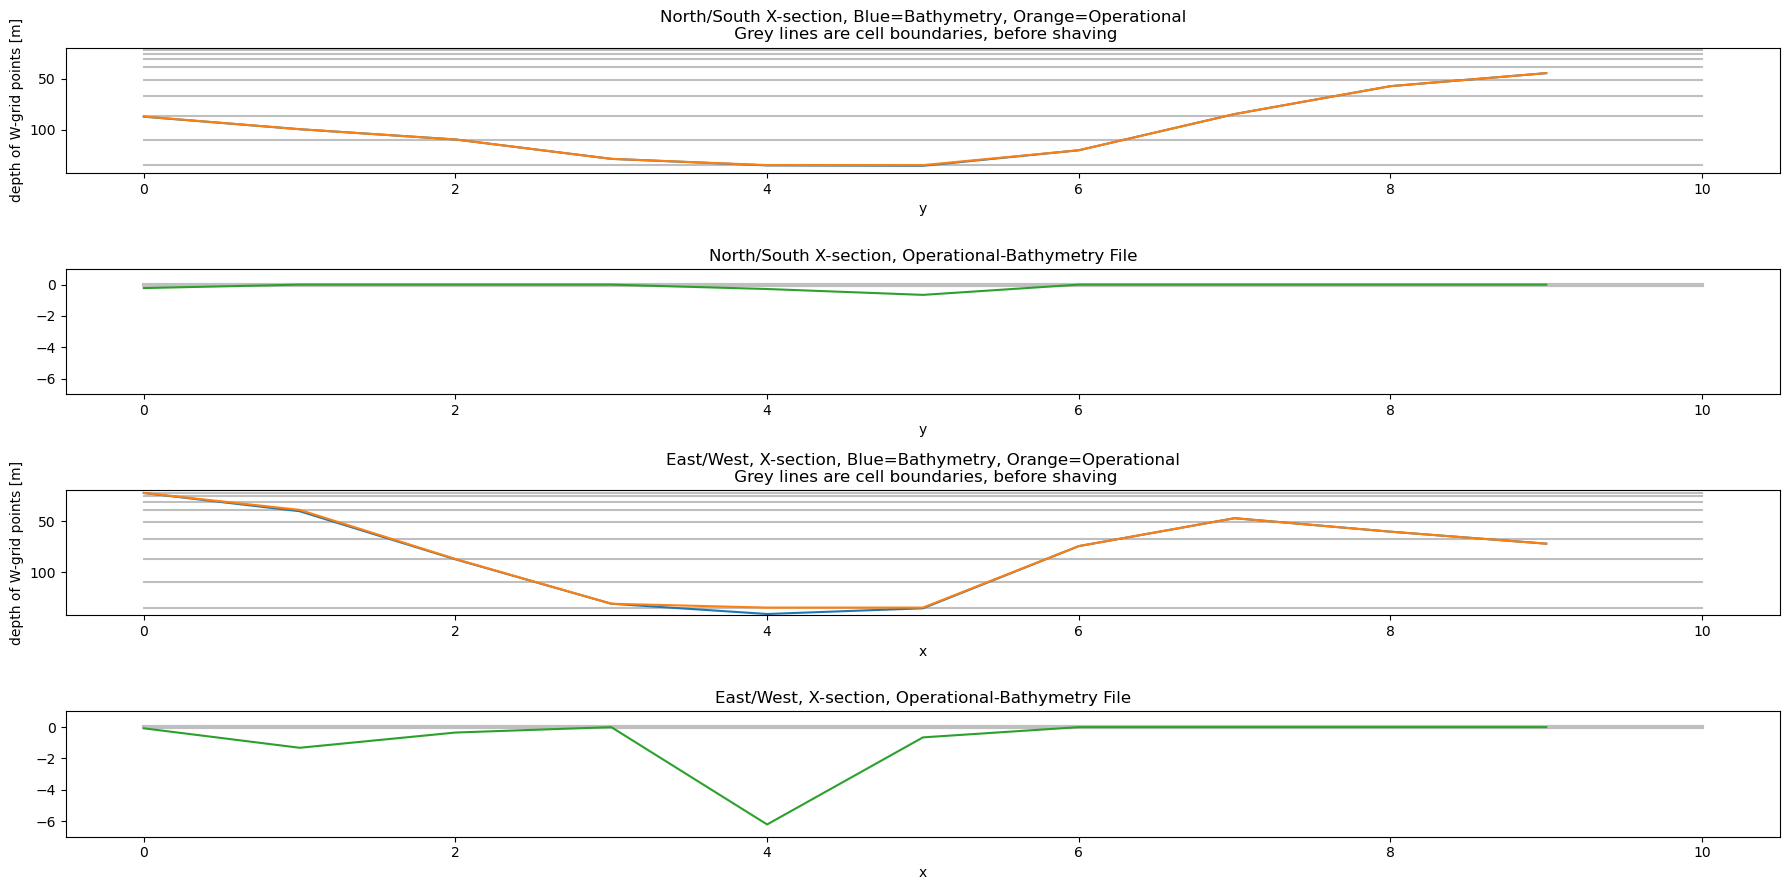

In [99]:
fig, axs = plt.subplots(4, 1, figsize=(18, 9))
for ax in [axs[0], axs[2]]:
    ax.invert_yaxis()
    ax.set_ylim(142, 20)
    for ik in range(20, 30):
        ax.plot([0, 10], [mesh.gdepw_1d[0, ik].values, mesh.gdepw_1d[0, ik].values], color='grey', alpha=0.5)
bathy.Bathymetry[ii-dd:ii+dd, jj].plot(ax=axs[0])
mesh.gdepw_0[0, mesh.mbathy[0, ii-dd:ii+dd, jj], ii-dd:ii+dd, jj].plot(ax=axs[0])
ax1= axs[1]
ax1.plot([0, 10], [0, 0], color='grey', linewidth=3, alpha=0.5)
(mesh.gdepw_0[0, mesh.mbathy[0, ii-dd:ii+dd, jj], ii-dd:ii+dd, jj] -
    bathy.Bathymetry[ii-dd:ii+dd, jj]).plot(ax=ax1, color='tab:green')
ax1.set_ylim(-7, 1)


bathy.Bathymetry[ii, jj-dd:jj+dd].plot(ax=axs[2])
mesh.gdepw_0[0, mesh.mbathy[0, ii, jj-dd:jj+dd], ii, jj-dd:jj+dd].plot(ax=axs[2])
ax2 = axs[3]
ax2.plot([0, 10], [0, 0], color='grey', linewidth=3, alpha=0.5)
(mesh.gdepw_0[0, mesh.mbathy[0, ii, jj-dd:jj+dd], ii, jj-dd:jj+dd] -
    bathy.Bathymetry[ii, jj-dd:jj+dd]).plot(ax=ax2, color='tab:green')
ax2.set_ylim(-7, 1)

axs[0].set_title("North/South X-section, Blue=Bathymetry, Orange=Operational\n Grey lines are cell boundaries, before shaving")
axs[1].set_title("North/South X-section, Operational-Bathymetry File")
axs[2].set_title("East/West, X-section, Blue=Bathymetry, Orange=Operational\n Grey lines are cell boundaries, before shaving")
axs[3].set_title("East/West, X-section, Operational-Bathymetry File")
fig.tight_layout();

The largest changes is a point that would have an isolated cell.  That is shallowed to the cell boundary.  Cells just below the cell boundary are also shallowed to the cell boundary as there is a minimum cell thickness.